### Group members

|  Name   |  Surname   |     Email                            |    Student ID                                             |
| :-----: | :--------: | :----------------------------------: | :-----------------------------------------------------: |
| Ludovico  | Gorrieri   | `ludovico.gorrieri@studio.unibo.it`   |  0001199160 |
| Alessandro  | Capialbi | `alessandro.capialbi@studio.unibo.it`  | 0001191564 |
| Faezeh  | Sarlakifar | `faezeh.sarlakifar@studio.unibo.it`  | 0001164608 |

## Task 1 & 2

### Download the dataset

In [37]:
# Download course material (one time)
!wget https://github.com/nlp-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data

!git clone https://github.com/nlp-unibo/nlp-course-material.git
%cd "nlp-course-material/2025-2026/Assignment 1"

--2025-12-02 16:57:33--  https://github.com/nlp-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
data: Is a directory

Cannot write to ‘data’ (Success).
Cloning into 'nlp-course-material'...
remote: Enumerating objects: 424, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 424 (delta 0), reused 2 (delta 0), pack-reused 418 (from 1)
Receiving objects: 100% (424/424), 8.83 MiB | 6.17 MiB/s, done.
Resolving deltas: 100% (190/190), done.
/content/nlp-course-material/2025-2026/Assignment 1/nlp-course-material/2025-2026/Assignment 1


### **Tweet Preprocessing and Label Aggregation Script**

This script prepares the dataset of tweets for NLP tasks.
It handles text cleaning, tokenization, lemmatization, and label aggregation for supervised learning.
Below is a detailed explanation of each section.

#### 1. Importing Required Libraries:

    a) pandas / numpy → for data manipulation.
    b) re → regular expressions for text cleaning.
    c) nltk → for tokenization, POS tagging, and lemmatization.
    d) Counter → to count occurrences of labels and select the majority vote.

#### 2. Preparing NLTK Resources:

    This block ensures that all required NLTK corpora and models are available locally.
    If a resource is missing, it is automatically downloaded.

#### 3. Initializing Tools:

    WhitespaceTokenizer → splits text based on spaces (useful after cleaning).
    WordNetLemmatizer → reduces words to their base or dictionary form using WordNet.

#### 4. Helper Function: get_wordnet_key(pos_tag):
    This function maps Penn Treebank POS tags (e.g., NN, VB, JJ) to WordNet’s format (noun, verb, adjective, adverb).
    This step is essential because WordNetLemmatizer requires the part of speech to perform accurate lemmatization.

#### 5. Lemmatization Function: lem_text(row):
    Reduces words to their dictionary form (lemma) using POS information.
    
    This function:

    1) Tokenizes the tweet into words.
    2) Assigns POS tags using NLTK’s pos_tag.
    3) Lemmatizes each word according to its part of speech.
    4) Returns the lemmatized tweet as a single string.

#### 6. Cleaning Function: cleaner(row):

    Purpose: Remove noise and standardize text before analysis.

    Steps:

    1) lower(): Converts all text to lowercase
    2) Remove URLs: Regex https?:\/\/.\S+ removes URLs and links
    3) Remove mentions & hashtags:	Regex [@#].\S+ removes @user and #topic
    4) Remove emojis/symbols: Unicode ranges cover emoticons, flags, pictographs
    5) Remove non-alphanumeric:	Keeps only letters, digits, and spaces
    6) Normalize whitespace:	Collapses multiple spaces into one

#### 7. Label Aggregation:

    This part aggregates multiple label votes for a tweet into a single numeric label.

    How it works:

    1) For each row, it collects all values in labels_task2 except "UNKNOWN".
    2) Uses Counter to find the most common label (majority vote).
    3) Maps that label to a numerical ID using the mapping dictionary.

#### Summary

    This script prepares tweets by performing:

    1) cleaner():	Remove unwanted characters and normalize text
    2) lem_text(): Lemmatize words for consistent representation
    3) aggregator(): Convert multiple annotations into a single label

    Together, these functions create a clean, normalized, and labeled dataset,
    ideal for tasks like text classication that we will perform.


In [38]:
# Imports
import os
import json
import re
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# NLTK setup
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize, sent_tokenize, WhitespaceTokenizer

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models


# Gensim / GloVe
!pip install gensim
import gensim
from gensim.models import KeyedVectors

In [39]:
import os
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
glove_dst = "/content/drive/MyDrive/glove.twitter.27B.200d.txt"
glove_src = "glove.twitter.27B.200d.txt"

if os.path.exists(glove_dst):
    print("GloVe file already exists in Drive.")
else:
    print("Downloading GloVe file...")
    !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
    !unzip -q glove.twitter.27B.zip
    print("Copying GloVe file to Drive...")
    !cp "$glove_src" "$glove_dst"
    print("File copied successfully!")

glove_file = glove_dst


GloVe file already exists in Drive.


In [41]:
# Prepare NLTK resources
resources = [
    ('corpora/omw-1.4', 'omw-1.4'),
    ('corpora/wordnet', 'wordnet'),
    ('taggers/averaged_perceptron_tagger', 'averaged_perceptron_tagger'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('tokenizers/punkt', 'punkt')
]

# Ensure that all the required NLTK resources are downloaded.
# If a resource is missing, it is downloaded quietly (without console output).
for resource_path, download_name in resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

# Initialize tokenizer and lemmatizer
tokenizer = WhitespaceTokenizer()
lemmatizer = WordNetLemmatizer()

def get_wordnet_key(pos_tag):
    """
    Map POS (Part-of-Speech) tags from the Penn Treebank format
    to the corresponding WordNet POS tags.

    Args:
        pos_tag (str): The POS tag from NLTK's `pos_tag` function.

    Returns:
        str: Corresponding WordNet POS tag (ADJ, VERB, NOUN, ADV).
             Defaults to 'n' (noun) if no match is found.
    """
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

def lem_text(row):
    """
    Lemmatize a tweet using NLTK's WordNet lemmatizer.

    Steps:
        1. Tokenize the tweet by whitespace.
        2. Tag each token with its POS.
        3. Lemmatize each token using its WordNet POS tag.
        4. Join the lemmatized tokens back into a single string.

    Args:
        row (pd.Series): A row from a pandas DataFrame containing a 'tweet' field.

    Returns:
        str: The lemmatized version of the tweet.
    """
    tokens = tokenizer.tokenize(row.tweet)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

def cleaner(row):
    """
    Normalize and clean a tweet by removing unwanted elements.

    Steps:
        - Convert to lowercase.
        - Remove URLs, mentions, and hashtags.
        - Remove emojis and special Unicode characters.
        - Remove non-alphanumeric characters.
        - Remove excessive whitespace.

    Args:
        row (pd.Series): A row from a pandas DataFrame containing a 'tweet' field.

    Returns:
        str: The cleaned tweet text.
    """
    text = row.tweet
    text = text.lower()
    text = re.sub(r'https?:\/\/.\S+', '', text)         # Remove URLs
    text = re.sub(r'[@#].\S+', '', text)                # Remove mentions and hashtags
    text = re.sub(
        "["                                             # Remove emojis and symbols
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # Flags
        "]+", '', text
    )
    text = re.sub(r'[^a-z^0-9^\s]*', '', text)         # Remove non-alphanumeric chars
    text = ' '.join(text.split())                      # Remove extra spaces
    return text

# Define a mapping for label aggregation
mapping = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}

# Aggregate multiple labels into a single class value based on majority voting.
# If there are multiple annotations for a tweet, the most common label (excluding "UNKNOWN")
# is selected and mapped to its numeric representation using the 'mapping' dictionary.
aggregator = lambda row: \
    mapping[Counter([vote for vote in row.labels_task2 if vote != "UNKNOWN"]).most_common(1)[0][0]]

### Clean, split and lemmatize the dataset.

In [42]:
# Load the files
with open("data/training.json", "r") as tr, \
     open("data/validation.json", "r") as te, \
     open("data/test.json", "r") as va:
    train_json = json.load(tr)
    val_json = json.load(te)
    test_json = json.load(va)

# Create the dataframes (setting the index to id_EXIST)
dts = {
    "train": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST")
}

# Unnecessary columns
drop_cols = ["number_annotators", "annotators", "gender_annotators",
    "age_annotators", "labels_task1", "labels_task3", "split"]

# Clean and lemmatize the data
for name, df in dts.items():
    df = df[df.lang == "en"] # Drop spanish.

    df = df.drop(columns=drop_cols) # Drop unnecessary cols.

    df["labels"] = df.apply(aggregator, axis=1) # Aggregate the labels (maj. voting).
    df = df.drop(columns="labels_task2")

    for func in [cleaner, lem_text]:
        df["tweet"] = df.apply(func, axis=1) # Clean the tweets.

    dts[name] = df

train, test, val = dts.values()

## Task 3: Text Encoding

### Text Encoding for Neural Sexism Classifier

 The goal is to produce a clear, reproducible pipeline that: builds a vocabulary, initializes embeddings from GloVe where available, creates embeddings for train-set-only tokens, and assigns a special `<UNK>` embedding for new tokens encountered in validation/test sets.

---

#### 1. Goal and constraints

* Embed words using pre-trained **GloVe** vectors (we chose `glove.twitter.27B.100d.txt` in the code).
* **All tokens present in the training set must be included in the vocabulary** and must have an embedding (from GloVe if available, or a custom embedding if not).
* Tokens that appear only in validation/test but not in training must be mapped to a special token (for example `<UNK>`), which has a **static** embedding (the same embedding for every OOV token in val/test).
* We may choose how to build the `static/<UNK>` embedding (random, neighbourhood average, or other strategy).

---

#### 2. Vocabulary design

1. **Train-only vocabulary**

   * Vocabulary = all distinct tokens from the training set.
   * Guarantees every train token has an entry and an embedding.
   * Any token in val/test not in this vocabulary becomes `<UNK>`.

> We implemented a `TextVectorization` layer to build the vocabulary from the training data.

---

#### 3. High-level pipeline

1. **Prepare datasets**

   * Extract `texts` and `labels` for `train`, `val`, `test` and create `tf.data.Dataset` objects batched with `batch(64)`.
   * Example from the code: `train_ds = tf.data.Dataset.from_tensor_slices((texts, labels)).batch(64)`.

2. **Build a TextVectorization layer**

   * `vectorizer = layers.TextVectorization(max_tokens=20000, output_sequence_length=100)`.
   * Fit it on the training texts: `vectorizer.adapt(train_ds.map(lambda x, y: x))`.
   * This produces a vocabulary `vocab = vectorizer.get_vocabulary()`.

3. **Load GloVe**

   * Use Gensim's `KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)` to load `glove.twitter.27B.100d.txt` into memory.
   * `embedding_dim = twitter_glove.vector_size` (100 in the example).

4. **Construct embedding matrix**

   * Initialize `embedding_matrix = np.zeros((len(vocab), embedding_dim))`.
   * For each word in `vocab`:

     * If `word` exists in `twitter_glove`, set `embedding_matrix[i] = twitter_glove[word]`.
     * Else (train-only OOV): set `embedding_matrix[i] = some_custom_embedding` (your code uses `np.random.normal(scale=0.6, size=(embedding_dim,))`).

5. **Create a special `<UNK>` token for val/test OOVs**

   * Ensure the vectorizer (or token-to-index mapping) reserves an index for a special token (e.g., `'<UNK>'`) or use the 0 index for padding and a fixed index (e.g., `1`) for `<UNK>`.
   * In our mapping, tokens in val/test not present in the vocabulary must be converted to the index of `<UNK>` before being fed to the model.
   * Give `<UNK>` a static embedding (recommended: deterministic seed or computed average).

6. **Initialize Keras Embedding layer**

   * `embedding_layer = layers.Embedding(input_dim=len(vocab), output_dim=embedding_dim, embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix), trainable=True)`
   * `trainable=True` allows fine-tuning of pre-trained embeddings and learns OOV embeddings during training.

---

#### 4. Details: Handling OOV tokens (train vs. val/test)

* **Token in train set but not in GloVe** (train-only OOV):

  * Must be *added* to the vocabulary and assigned an embedding.
  * Our code initializes these rows with random normal vectors: `np.random.normal(scale=0.6, size=(embedding_dim,))`.
  * Because `embedding_layer` is `trainable=True`, these vectors get adjusted during training.

* **Token not in train set but appears in val/test** (val/test OOV):

  * Must be mapped to `<UNK>` (single special token index) so they don't introduce new indices not covered by `embedding_matrix`.
  * `<UNK>` must have a static embedding which remains constant *until* (optionally) you let the model train it. The task statement asks for a static embedding — we can still allow training, but the wording suggests a fixed initialization.


### Setup

In [66]:
# Set the Keras backend to TensorFlow
# This ensures that all Keras operations are executed using TensorFlow as the underlying framework.
os.environ["KERAS_BACKEND"] = "tensorflow"


### Build the vocabulary

In [67]:
pip install nlpaug

In [68]:
# Extract tweet texts and corresponding labels from the training set
texts = train["tweet"].values
labels = train["labels"].values
print(f"Original train examples: {len(texts)}")

# Extract validation data (texts and labels)
valid_texts = val["tweet"].values
valid_labels = val["labels"].values
print(f"Validation examples: {len(valid_texts)}")

# Extract test data (texts and labels)
test_texts = test["tweet"].values
test_labels = test["labels"].values
print(f"Test examples: {len(test_labels)}")


Original train examples: 3260
Validation examples: 177
Test examples: 312


In [69]:
"""import nlpaug.augmenter.word as naw
import nlpaug.flow as naf

# Apply NLPAug (EDA Techniques)

# Define the 4 EDA techniques
# 1. Synonym Replacement (SR) using Word Embeddings
# We use WordEmbsAug, which finds the closest words in the vector space.
aug_sr = naw.WordEmbsAug(
    model_type='glove',
    model_path=glove_file,
    action="substitute",  # Specify "substitute" for SR
    aug_p=0.5
)

# 2. Random Insertion (RI) using Word Embeddings
# We use the same augmenter, but change the action to "insert"
aug_ri = naw.WordEmbsAug(
    model_type='glove',
    model_path=glove_file,
    action="insert",      # Specify "insert" for RI
    aug_p = 0.8
)

# 3. Random Swap (RS)
aug_rs = naw.RandomWordAug(action="swap", aug_p=0.8)

# 4. Random Deletion (RD)
aug_rd = naw.RandomWordAug(action="delete", aug_p=0.3)"""

'import nlpaug.augmenter.word as naw\nimport nlpaug.flow as naf\n\n# Apply NLPAug (EDA Techniques)\n\n# Define the 4 EDA techniques\n# 1. Synonym Replacement (SR) using Word Embeddings\n# We use WordEmbsAug, which finds the closest words in the vector space.\naug_sr = naw.WordEmbsAug(\n    model_type=\'glove\',\n    model_path=glove_file,\n    action="substitute",  # Specify "substitute" for SR\n    aug_p=0.5\n)\n\n# 2. Random Insertion (RI) using Word Embeddings\n# We use the same augmenter, but change the action to "insert"\naug_ri = naw.WordEmbsAug(\n    model_type=\'glove\',\n    model_path=glove_file,\n    action="insert",      # Specify "insert" for RI\n    aug_p = 0.8\n)\n\n# 3. Random Swap (RS)\naug_rs = naw.RandomWordAug(action="swap", aug_p=0.8)\n\n# 4. Random Deletion (RD)\naug_rd = naw.RandomWordAug(action="delete", aug_p=0.3)'

In [70]:
"""print("\nStarting data augmentation using EDA...")

# Create an augmentation pipeline that randomly picks ONE of the 4 techniques
# We apply this pipeline to each sample we want to augment.
# p=1.0 means 100% of samples passed to it will be augmented by one of the methods.
augmentation_pipeline = naf.Sometimes(
    [aug_sr, aug_ri, aug_rs, aug_rd],
    aug_p=1.0
)

# We assume class 0 is the majority class and should not be augmented.

minority_mask = (labels == 1) | (labels == 2) | (labels == 3)
minority_texts = texts[minority_mask]
minority_labels = labels[minority_mask]

# Generate new synthetic data by augmenting the minority class texts
augmented_texts = [
    augmentation_pipeline.augment(t) for t in minority_texts
]

augmented_texts = [a[0] if isinstance(a, list) else a for a in augmented_texts]

print(f"Generated {len(augmented_texts)} new synthetic samples.")

# Combine the original data with the new augmented data
final_train_texts = np.concatenate((texts, augmented_texts))
final_train_labels = np.concatenate((labels, minority_labels))

# Shuffle the combined training data
indices = np.arange(len(final_train_texts))
np.random.shuffle(indices)
final_train_texts = final_train_texts[indices]
final_train_labels = final_train_labels[indices]

print(f"New total train size: {len(final_train_texts)}")"""

'print("\nStarting data augmentation using EDA...")\n\n# Create an augmentation pipeline that randomly picks ONE of the 4 techniques\n# We apply this pipeline to each sample we want to augment.\n# p=1.0 means 100% of samples passed to it will be augmented by one of the methods.\naugmentation_pipeline = naf.Sometimes(\n    [aug_sr, aug_ri, aug_rs, aug_rd],\n    aug_p=1.0\n)\n\n# We assume class 0 is the majority class and should not be augmented.\n\nminority_mask = (labels == 1) | (labels == 2) | (labels == 3)\nminority_texts = texts[minority_mask]\nminority_labels = labels[minority_mask]\n\n# Generate new synthetic data by augmenting the minority class texts\naugmented_texts = [\n    augmentation_pipeline.augment(t) for t in minority_texts\n]\n\naugmented_texts = [a[0] if isinstance(a, list) else a for a in augmented_texts]\n\nprint(f"Generated {len(augmented_texts)} new synthetic samples.")\n\n# Combine the original data with the new augmented data\nfinal_train_texts = np.concatenate(

In [71]:
aug_dataset = np.load('/content/drive/MyDrive/augmented_dataset.npz', allow_pickle=True)


In [72]:
"""import numpy as np

np.savez_compressed(
    "augmented_dataset.npz",
    texts=final_train_texts,
    labels=final_train_labels
)
print("File saved as 'augmented_dataset.npz'")
from google.colab import files
files.download("augmented_dataset.npz")

"""

'import numpy as np\n\nnp.savez_compressed(\n    "augmented_dataset.npz",\n    texts=final_train_texts,\n    labels=final_train_labels\n)\nprint("File saved as \'augmented_dataset.npz\'")\nfrom google.colab import files\nfiles.download("augmented_dataset.npz")\n\n'

In [73]:
import plotly.express as px
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

train_df = pd.DataFrame({"tweet": texts, "label": labels})
test_df = pd.DataFrame({"tweet": test_texts, "label": test_labels})

label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}
train_df["label_name"] = train_df["label"].map(label_map)
test_df["label_name"] = test_df["label"].map(label_map)

# Training Set figure
fig_train = px.histogram(
    train_df,
    x="label_name",
    color="label_name",
    title="Training Set Class Distribution",
    category_orders={"label_name": ["NOT SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]},
    color_discrete_sequence=px.colors.sequential.Plasma
)
fig_train.update_layout(
    xaxis_title="Class",
    yaxis_title="Count",
    showlegend=False,
    bargap=0.2
)

# Test Set figure
fig_test = px.histogram(
    test_df,
    x="label_name",
    color="label_name",
    title="Test Set Class Distribution",
    category_orders={"label_name": ["NOT SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]},
    color_discrete_sequence=px.colors.sequential.Plasma
)
fig_test.update_layout(
    xaxis_title="Class",
    yaxis_title="Count",
    showlegend=False,
    bargap=0.2
)

fig = make_subplots(rows=1, cols=2, subplot_titles=["Training Set", "Test Set"])

for trace in fig_train["data"]:
    fig.add_trace(trace, row=1, col=1)
for trace in fig_test["data"]:
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(
    title_text="Class Distribution Comparison",
    width=1100, height=400,
    showlegend=False
)

fig.show()


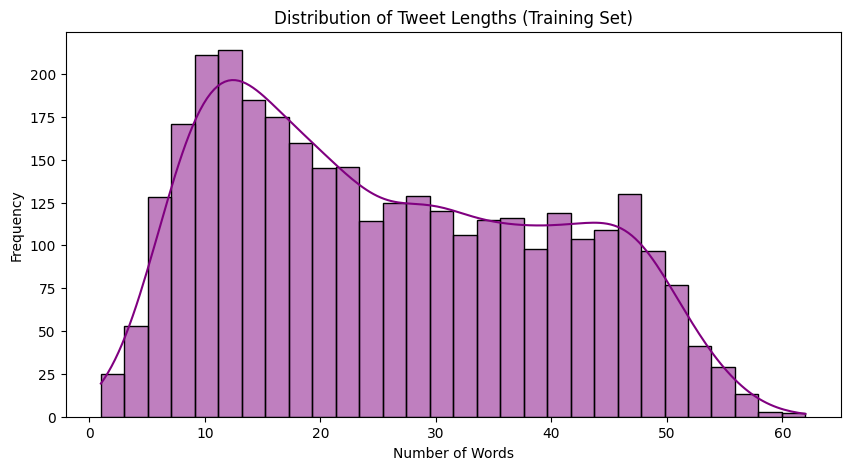

In [74]:
train_df["tweet_length"] = train_df["tweet"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(train_df["tweet_length"], bins=30, kde=True, color="purple")
plt.title("Distribution of Tweet Lengths (Training Set)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


/tmp/ipython-input-1428044963.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




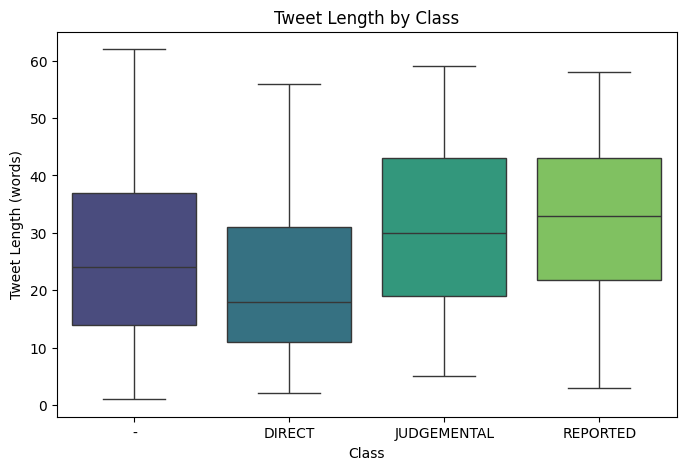

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="tweet_length", data=train_df, palette="viridis")
plt.title("Tweet Length by Class")
plt.xlabel("Class")
plt.ylabel("Tweet Length (words)")
plt.xticks([0,1,2,3], ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'])
plt.show()


In [76]:
import plotly.express as px
import pandas as pd

# Create DataFrame from augmented dataset
#final_train_texts, final_train_labels = aug_dataset["texts"], aug_dataset["labels"]
final_train_texts, final_train_labels = train_df["tweet"], train_df["label"]
train_df = pd.DataFrame({"tweet": final_train_texts, "label": final_train_labels})

# Map numeric labels to readable class names
label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGMENTAL", 3: "REPORTED"}
train_df["label_name"] = train_df["label"].map(label_map)

color_palette = px.colors.qualitative.Plotly

# Count occurrences and compute percentages
counts = train_df["label_name"].value_counts().reindex(["NOT SEXIST", "DIRECT", "JUDGMENTAL", "REPORTED"])
percentages = (counts / counts.sum() * 100).round(1)

# Create Plotly histogram
fig = px.histogram(
    train_df,
    x="label_name",
    color="label_name",
    title="Augmented Training Set Class Distribution",
    category_orders={"label_name": ["NOT SEXIST", "DIRECT", "JUDGMENTAL", "REPORTED"]},
    color_discrete_sequence=color_palette
)

fig.update_layout(
    xaxis_title="Class",
    yaxis_title="Count",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(color="black", size=13),
    showlegend=False,
    bargap=0.25
)

for i, label in enumerate(["NOT SEXIST", "DIRECT", "JUDGMENTAL", "REPORTED"]):
    fig.add_annotation(
        x=label,
        y=counts[label],
        text=f"{percentages[label]}%",
        showarrow=False,
        font=dict(color="black", size=12),
        yshift=8
    )

fig.show()


In [77]:
# Create a TensorFlow Dataset for training data
# Each batch contains 64 examples for efficient training
train_ds = tf.data.Dataset.from_tensor_slices((final_train_texts, final_train_labels)).batch(64)

# Create a TensorFlow Dataset for validation data
valid_ds = tf.data.Dataset.from_tensor_slices((valid_texts, valid_labels))

# Create a TensorFlow Dataset for test data
test_ds = tf.data.Dataset.from_tensor_slices((test_texts, test_labels)).batch(64)

In [78]:
# Initialize a TextVectorization layer
# - max_tokens: maximum vocabulary size (words beyond this limit are marked as "out of vocabulary")
# - output_sequence_length: maximum sequence length (texts are truncated or padded to this length)
vectorizer = layers.TextVectorization(max_tokens=20000, output_sequence_length=200)

# Adapt the vectorizer to the training data to build the vocabulary
# Only the text input (x) is passed for adaptation
vectorizer.adapt(train_ds.map(lambda x, y: x))

In [79]:
# Apply the same trained vectorizer to all dataset splits (train, validation, and test)
# Each text is transformed into a sequence of integer word indices
train_ds = train_ds.map(lambda x, y: (vectorizer(x), y))
valid_ds = valid_ds.map(lambda x, y: (vectorizer(x), y))
valid_ds = valid_ds.batch(64, drop_remainder=True)
test_ds  = test_ds.map(lambda x, y: (vectorizer(x), y))

In [80]:
# Retrieve the vocabulary from the vectorizer
vocab = vectorizer.get_vocabulary()

# Print the first 10 tokens in the vocabulary for inspection
print(vocab[:10])

['', '[UNK]', np.str_('be'), np.str_('the'), np.str_('a'), np.str_('to'), np.str_('and'), np.str_('of'), np.str_('i'), np.str_('it')]


The vectorizer has its vocabulary frozen after adapt().

When we apply it to the val or test set,

any word not seen during training will automatically be replaced with the OOV token (default **UNK**, index 1).

We do not need to manually preprocess or map OOV tokens, TensorFlow will handle it internally.

### Use GloVe Embedding vectors

#### Convert GloVe format to Word2Vec format

In [81]:
# Load pre-trained GloVe Twitter embeddings using Gensim
# - 'binary=False' since the GloVe file is in text format
# - 'no_header=True' because GloVe files do not contain a header line
twitter_glove = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)

# Print the total number of tokens (words) loaded from the GloVe model
print(f"Loaded Twitter GloVe with {len(twitter_glove.key_to_index):,} tokens")

Loaded Twitter GloVe with 1,193,514 tokens


#### Build TensorFlow embedding matrix

In [82]:
# Retrieve the vocabulary learned by the TextVectorization layer
vocab = vectorizer.get_vocabulary()

# Get the dimensionality of the GloVe embeddings (e.g., 200)
embedding_dim = twitter_glove.vector_size

# Initialize an empty embedding matrix
# Each row corresponds to a word in the vocabulary, initialized to zeros
embedding_matrix = np.zeros((len(vocab), embedding_dim))

### OOV handling

#### Random embedding initialization for OOV words

Then we will learn them by training

In [83]:
# Construct the embedding matrix using GloVe vectors or random initialization
# For each word in the vocabulary:
# - If the word exists in the pre-trained GloVe embeddings, use its vector.
# - Otherwise, initialize its vector with random values drawn from a normal distribution
#   (mean = 0, std = 0.6) to represent out-of-vocabulary (OOV) words.
count_0 = 0
count_1 = 0
for i, word in enumerate(vocab):
    if word in twitter_glove:
        embedding_matrix[i] = twitter_glove[word]
        count_0 += 1
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
        count_1 += 1
print(count_0)
print(count_1)

8446
2123


##### Create Keras Embedding layer

## Task 4 & 5

Improvements: Data Augmentation, Weight Decay, increasing embedding dimensions, plotting of the loss during training

In [84]:
from sklearn.utils.class_weight import compute_class_weight

# Assuming your labels are integers 0, 1, 2, 3
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

print("Computed class weights:", class_weights)

Computed class weights: {0: np.float64(0.3788935378893538), 1: np.float64(1.2714508580343213), 2: np.float64(3.918269230769231), 3: np.float64(3.1346153846153846)}


In [85]:
# The FocalLoss class definition is correct and remains unchanged
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=None, from_logits=False, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.convert_to_tensor(y_pred)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        y_true_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = -y_true_onehot * tf.math.log(tf.clip_by_value(y_pred, 1e-8, 1.0))

        if self.alpha is not None:
            # Apply the alpha weights
            alpha_factor = y_true_onehot * self.alpha
            cross_entropy *= alpha_factor

        focal_weight = tf.pow(1 - y_pred, self.gamma)
        loss = focal_weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)


classes = [0, 1, 2, 3]

# Calculate counts using the AUGMENTED training labels
class_counts = np.array([np.sum(final_train_labels == c) for c in classes])
print("Augmented class counts:", class_counts)

# 2. Calculate total samples from the augmented training set
total_train_samples = len(final_train_labels)

# 3. Calculate alpha (inverse frequency) based on the correct data
alpha = total_train_samples / (len(class_counts) * class_counts)

# 4. Normalize alpha (so weights sum to 1)
alpha = alpha / alpha.sum()

# 5. Convert to a TensorFlow constant to pass into the loss function
alpha = tf.constant(alpha, dtype=tf.float32)

print("Corrected Alpha values (based on augmented train set):", alpha)

Augmented class counts: [2151  641  208  260]
Corrected Alpha values (based on augmented train set): tf.Tensor([0.04353482 0.14608955 0.45020866 0.36016694], shape=(4,), dtype=float32)


#### Bidirectional LSTM Dense Layer


Training baseline model with seed 42...

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.91      0.65      0.76        91
      DIRECT       0.35      0.79      0.48        19
 JUDGEMENTAL       0.00      0.00      0.00         9
    REPORTED       0.25      0.22      0.24         9

    accuracy                           0.59       128
   macro avg       0.38      0.42      0.37       128
weighted avg       0.71      0.59      0.63       128

---------------------------------

Plotting Confusion Matrix...


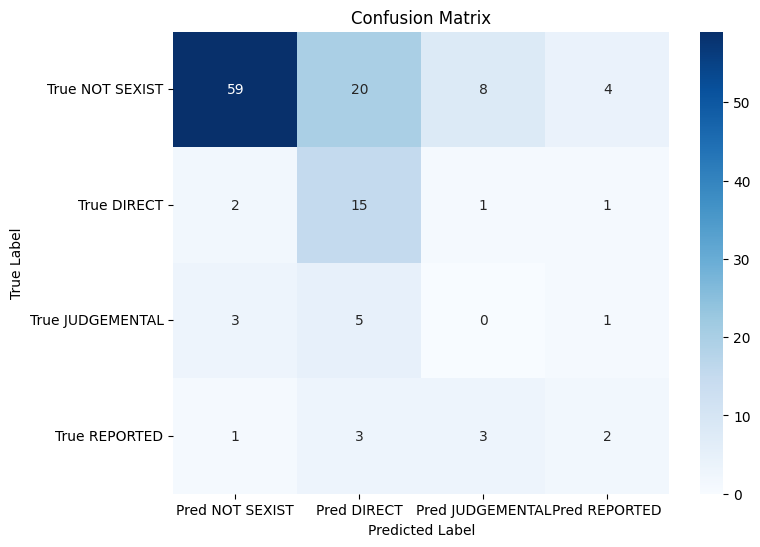


Training stacked model with seed 42...

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.87      0.59      0.71        91
      DIRECT       0.27      0.68      0.38        19
 JUDGEMENTAL       0.11      0.11      0.11         9
    REPORTED       0.25      0.22      0.24         9

    accuracy                           0.55       128
   macro avg       0.37      0.40      0.36       128
weighted avg       0.68      0.55      0.58       128

---------------------------------

Plotting Confusion Matrix...


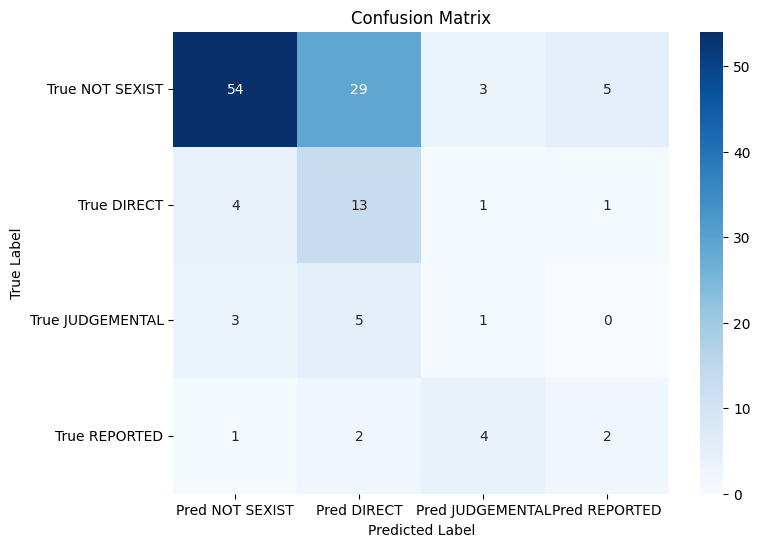


Training baseline model with seed 123...

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.85      0.43      0.57        91
      DIRECT       0.25      0.68      0.36        19
 JUDGEMENTAL       0.09      0.22      0.13         9
    REPORTED       0.29      0.22      0.25         9

    accuracy                           0.44       128
   macro avg       0.37      0.39      0.33       128
weighted avg       0.67      0.44      0.49       128

---------------------------------

Plotting Confusion Matrix...


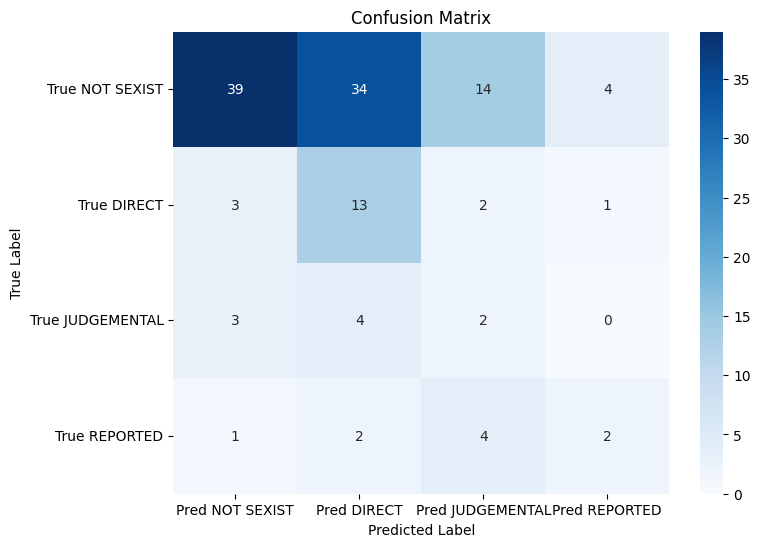


Training stacked model with seed 123...

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.90      0.38      0.54        91
      DIRECT       0.21      0.63      0.32        19
 JUDGEMENTAL       0.08      0.22      0.11         9
    REPORTED       0.29      0.22      0.25         9

    accuracy                           0.40       128
   macro avg       0.37      0.37      0.31       128
weighted avg       0.70      0.40      0.46       128

---------------------------------

Plotting Confusion Matrix...


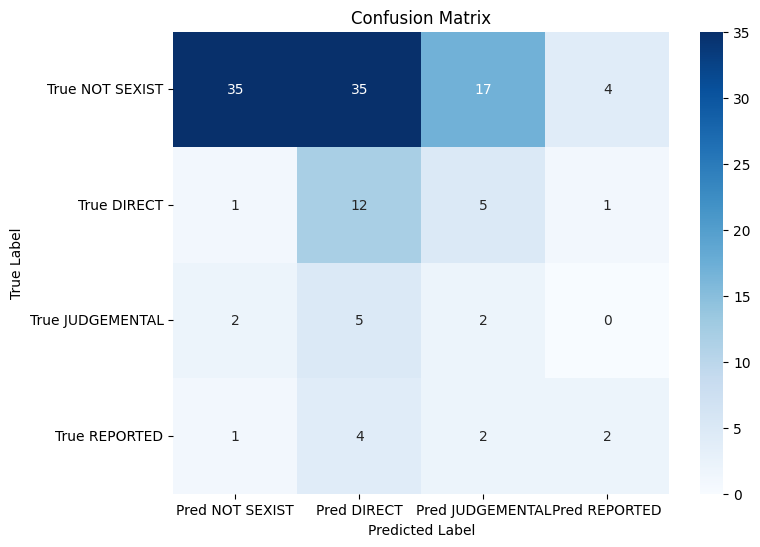


Training baseline model with seed 999...



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.85      0.57      0.68        91
      DIRECT       0.28      0.68      0.40        19
 JUDGEMENTAL       0.00      0.00      0.00         9
    REPORTED       0.33      0.33      0.33         9

    accuracy                           0.53       128
   macro avg       0.37      0.40      0.35       128
weighted avg       0.67      0.53      0.57       128

---------------------------------

Plotting Confusion Matrix...


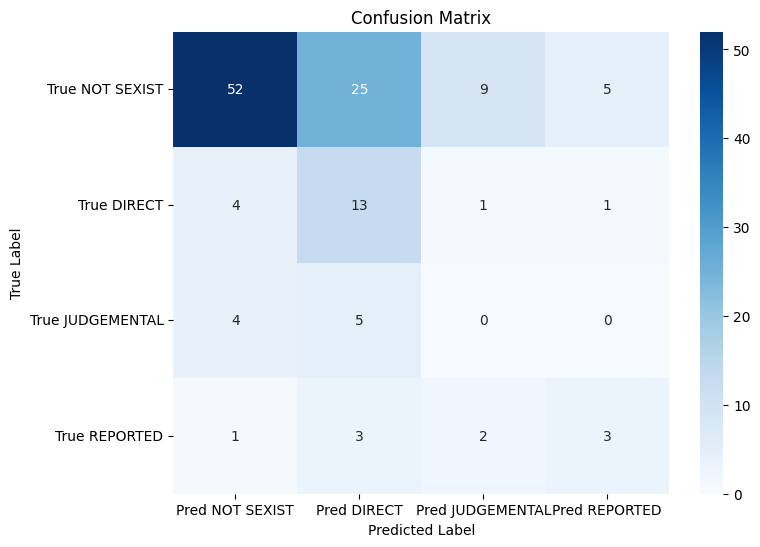


Training stacked model with seed 999...



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.88      0.48      0.62        91
      DIRECT       0.27      0.84      0.41        19
 JUDGEMENTAL       0.07      0.11      0.08         9
    REPORTED       0.67      0.22      0.33         9

    accuracy                           0.49       128
   macro avg       0.47      0.41      0.36       128
weighted avg       0.72      0.49      0.53       128

---------------------------------

Plotting Confusion Matrix...


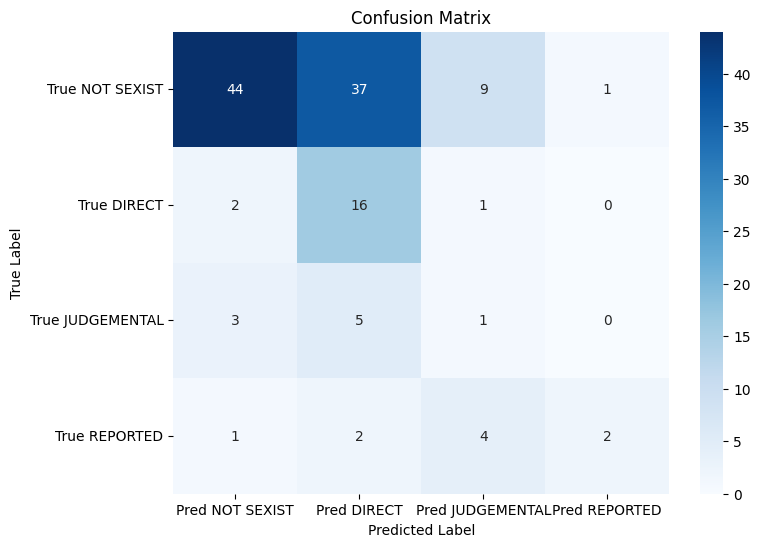


Retraining best base model with seed 42...

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.91      0.65      0.76        91
      DIRECT       0.35      0.79      0.48        19
 JUDGEMENTAL       0.00      0.00      0.00         9
    REPORTED       0.25      0.22      0.24         9

    accuracy                           0.59       128
   macro avg       0.38      0.42      0.37       128
weighted avg       0.71      0.59      0.63       128

---------------------------------

Plotting Confusion Matrix...


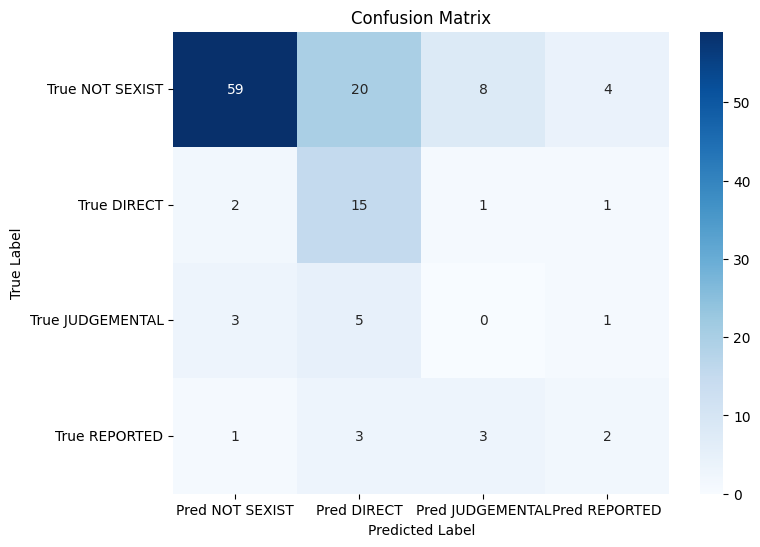

Best model saved as 'best_base_model.keras'

Retraining best stacked model with seed 999...

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.88      0.48      0.62        91
      DIRECT       0.27      0.84      0.41        19
 JUDGEMENTAL       0.07      0.11      0.08         9
    REPORTED       0.67      0.22      0.33         9

    accuracy                           0.49       128
   macro avg       0.47      0.41      0.36       128
weighted avg       0.72      0.49      0.53       128

---------------------------------

Plotting Confusion Matrix...


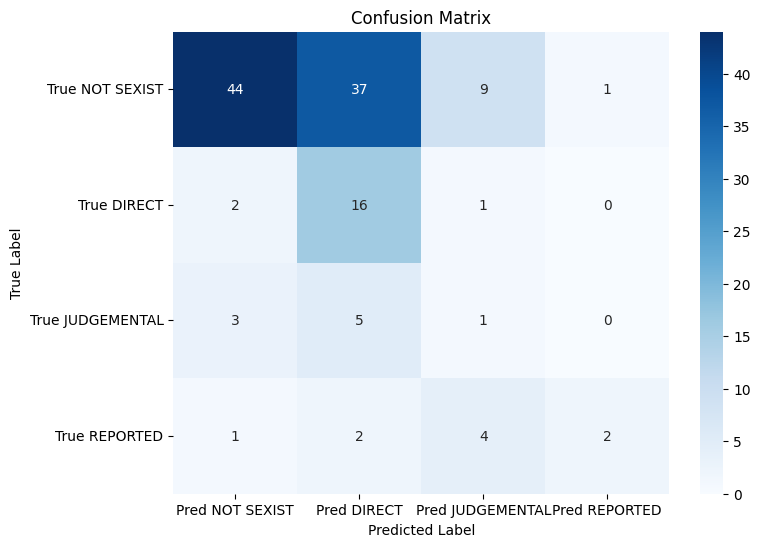

Best model saved as 'best_stacked_model.keras'


In [86]:
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from itertools import product
import tensorflow as tf # Ensure tensorflow is imported

# Custom Keras Metric for Macro F1-Score
class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1_score', **kwargs):
        super(MacroF1, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        # Reshape y_true and y_pred to (batch_size, 1) for broadcasting
        y_true_reshaped = tf.expand_dims(y_true, axis=-1)
        y_pred_reshaped = tf.expand_dims(y_pred, axis=-1)

        # Create class_range tensor (e.g., [0, 1, 2, 3])
        class_range = tf.range(self.num_classes, dtype=tf.int32)

        # Compare true labels with each class. Result: (batch_size, num_classes)
        true_class_masks = tf.equal(y_true_reshaped, class_range)
        # Compare predicted labels with each class. Result: (batch_size, num_classes)
        pred_class_masks = tf.equal(y_pred_reshaped, class_range)

        # Calculate True Positives (y_true == c AND y_pred == c) for all classes
        tp_batch = tf.reduce_sum(tf.cast(tf.logical_and(true_class_masks, pred_class_masks), tf.float32), axis=0)
        # Calculate False Positives (y_true != c AND y_pred == c) for all classes
        fp_batch = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(true_class_masks), pred_class_masks), tf.float32), axis=0)
        # Calculate False Negatives (y_true == c AND y_pred != c) for all classes
        fn_batch = tf.reduce_sum(tf.cast(tf.logical_and(true_class_masks, tf.logical_not(pred_class_masks)), tf.float32), axis=0)

        self.true_positives.assign_add(tp_batch)
        self.false_positives.assign_add(fp_batch)
        self.false_negatives.assign_add(fn_batch)

    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + tf.keras.backend.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + tf.keras.backend.epsilon())
        f1_scores = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
        return tf.reduce_mean(f1_scores)

    def reset_state(self):
        self.true_positives.assign(np.zeros((self.num_classes,)))
        self.false_positives.assign(np.zeros((self.num_classes,)))
        self.false_negatives.assign(np.zeros((self.num_classes,)))

# Hyperparameters
LSTM_UNITS = 256
DROPOUT_RATE = 0.75
LR = 1e-4
EPOCHS = 30
SEEDS = [42, 123, 999]
L2_FACTOR = 1e-4

# Build model
def build_model(stacked=False):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            mask_zero=True,
            trainable=False,
            name='encoder-embedding'
        ),
        layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=stacked, kernel_regularizer=regularizers.l2(L2_FACTOR),
        recurrent_regularizer=regularizers.l2(L2_FACTOR))),
        #layers.LayerNormalization(),
        layers.Dropout(DROPOUT_RATE),
        layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=False, kernel_regularizer=regularizers.l2(L2_FACTOR),
        recurrent_regularizer=regularizers.l2(L2_FACTOR))) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        layers.Dropout(DROPOUT_RATE) if stacked else layers.Identity(),
        # Add a Dense layer
        layers.Dense(
            64,
            activation = "leaky_relu",
            kernel_regularizer=regularizers.l2(L2_FACTOR)
        ),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        loss=FocalLoss(gamma = 2.0, alpha = alpha),
        optimizer=optimizers.Adam(learning_rate=LR),
        metrics=['accuracy', MacroF1(num_classes=len(classes))] # Added custom MacroF1 metric
    )
    return model

# Evaluation helper
@tf.function(reduce_retracing=True)
def predict_batch(model, x):
    return model(x, training=False)

def evaluate_model(model, valid_ds, class_names=['NOT SEXIST', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']):
    """
    Compute macro F1, precision, recall, and display classification report
    and confusion matrix on the validation set.
    """
    y_true = []
    y_pred_probs = []

    # Iterate over the validation dataset
    for x_batch, y_batch in valid_ds:
        # Get model predictions (probabilities) using the tf.function
        preds = predict_batch(model, x_batch)

        # Store true labels (ground truth)
        y_true.extend(y_batch.numpy())
        # Store predicted probabilities
        y_pred_probs.extend(preds.numpy())

    # Get the predicted class index (the one with the highest probability)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 1. Print the detailed Classification Report
    # This shows precision, recall, f1-score for each class
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("---------------------------------")

    # 2. Compute and display the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\nPlotting Confusion Matrix...")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {name}' for name in class_names],
                yticklabels=[f'True {name}' for name in class_names])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Calculate macro-averaged metrics
    # 'macro' calculates metrics for each label, and finds their unweighted mean.
    # This is crucial for imbalanced datasets.
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    return f1, prec, rec

# Early stopping callback (prevents overfitting)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_macro_f1_score', # Monitor the custom F1 score
    mode='max',
    patience=5,
    restore_best_weights=True
)

# Main training loop
f1_scores_base, precisions_base, recalls_base = [], [], []
f1_scores_stacked, precisions_stacked, recalls_stacked = [], [], []

for seed, stacked in list(product(SEEDS, [False, True])):
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    tf.keras.utils.set_random_seed(seed)

    model = build_model(stacked)
    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        callbacks=[early_stop],
        verbose=0
    )
    f1, prec, rec = evaluate_model(model, valid_ds)
    f1_scores_stacked.append(f1) if stacked else f1_scores_base.append(f1)
    precisions_stacked.append(prec) if stacked else precisions_base.append(f1)
    recalls_stacked.append(rec) if stacked else recalls_base.append(rec)

history_best = []
for stacked in [False, True]:
    # Train and save best model
    best_seed = SEEDS[np.argmax(f1_scores_stacked if stacked else f1_scores_base)]
    print(f"\nRetraining best {"stacked" if stacked else "base"} model with seed {best_seed}...")
    tf.keras.utils.set_random_seed(best_seed)
    best_model = build_model(stacked)
    history_best.append(best_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        callbacks=[early_stop],
        verbose=0
    ))
    evaluation = evaluate_model(best_model, valid_ds)
    best_model.save(f"best_{"stacked" if stacked else "base"}_model.keras")
    print(f"Best model saved as 'best_{"stacked" if stacked else "base"}_model.keras'")

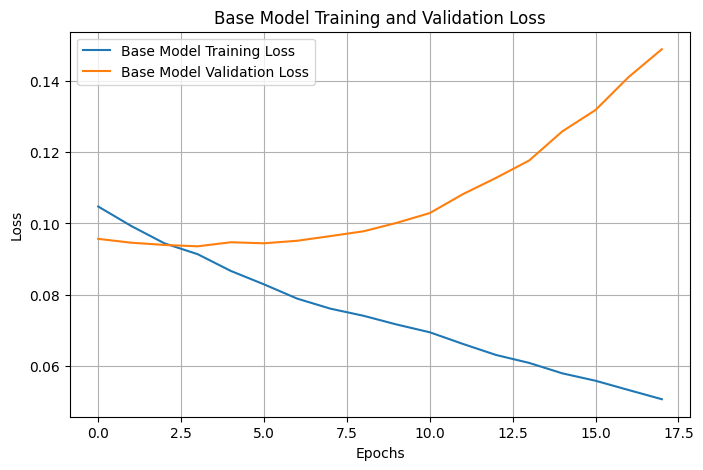

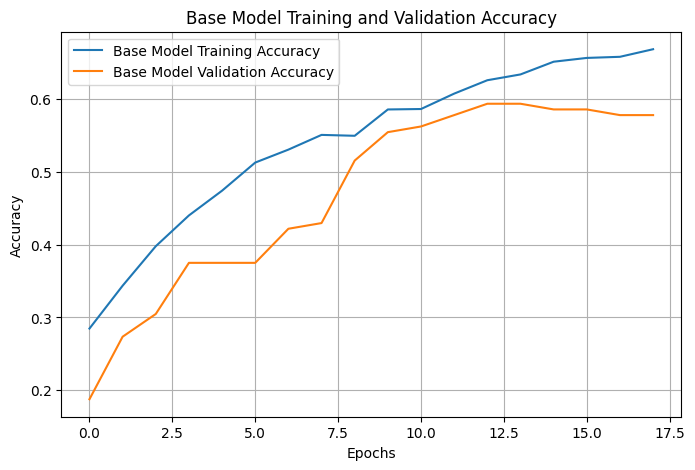

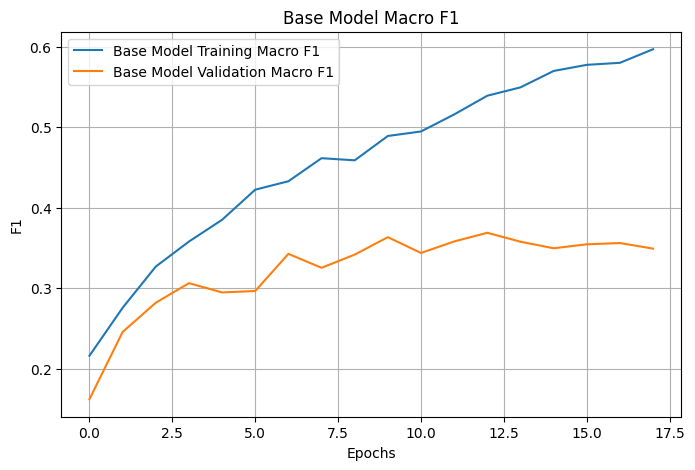

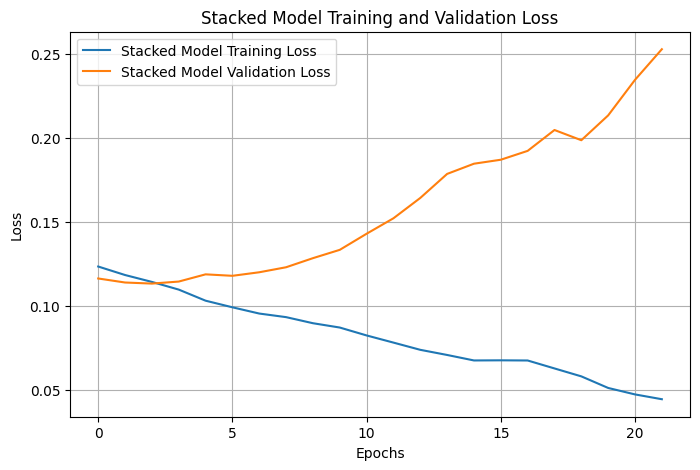

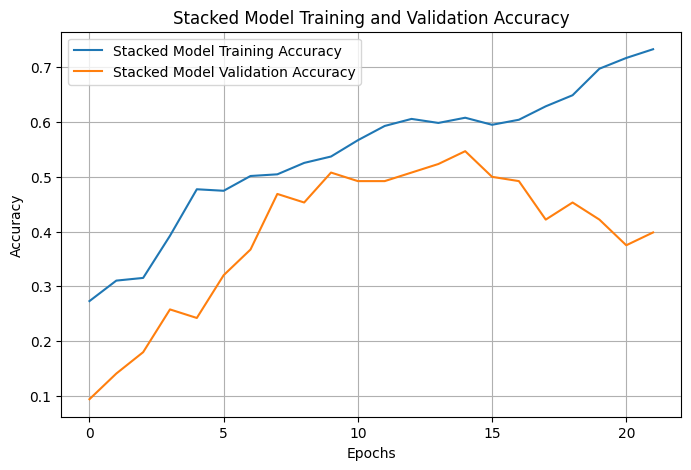

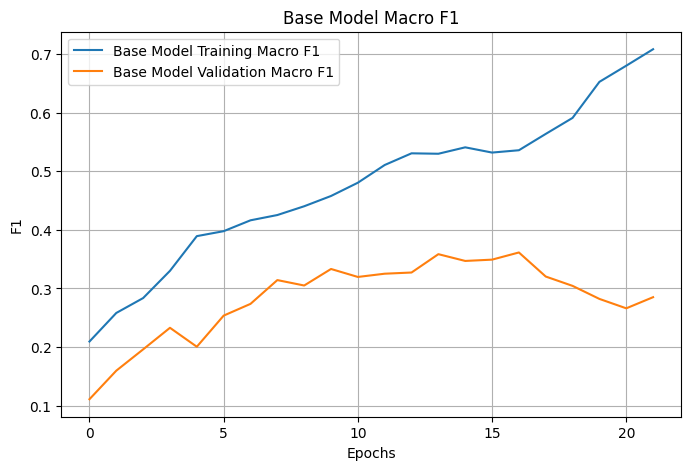

In [87]:


#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0].history['loss'], label='Base Model Training Loss')
plt.plot(history_best[0].history['val_loss'], label='Base Model Validation Loss')
plt.title('Base Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0].history['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0].history['val_accuracy'], label='Base Model Validation Accuracy')
plt.title('Base Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[0].history['macro_f1_score'], label='Base Model Training Macro F1')
plt.plot(history_best[0].history['val_macro_f1_score'], label='Base Model Validation Macro F1')
plt.title('Base Model Macro F1')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[1].history['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1].history['val_loss'], label='Stacked Model Validation Loss')
plt.title('Stacked Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[1].history['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1].history['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title('Stacked Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1].history['macro_f1_score'], label='Base Model Training Macro F1')
plt.plot(history_best[1].history['val_macro_f1_score'], label='Base Model Validation Macro F1')
plt.title('Base Model Macro F1')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
"""from sklearn.model_selection import KFold
from itertools import product
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import load_model

# Convert texts to sequences
X_train_seq = np.array(vectorizer(texts))
y_train = np.array(labels)

# Normalize embedding matrix for numerical stability
embedding_matrix = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Function to build a Bidirectional LSTM model
def build_model(lstm_units=64, dropout_rate=0.2, trainable_embeddings=True, lr=1e-3):

    # Build and compile a Bidirectional LSTM model with embedding layer and softmax output.

    embedding_layer_current = layers.Embedding(
        input_dim=len(vocab),
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=trainable_embeddings,
        name='encoder-embedding'
    )

    model = models.Sequential([
        embedding_layer_current,
        layers.Bidirectional(layers.LSTM(lstm_units)),
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax')  # 4 classes output
    ])

    optimizer = optimizers.Adam(learning_rate=lr)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Hyperparameter grid
param_grid = {
    'lstm_units': [256, 512],
    'lr': [1e-3, 1e-4],
    'batch_size': [64, 128],
    'dropout_rate': [0.2, 0.3, 0.4],
    'trainable_embeddings': [True, False]
}


# Generate all hyperparameter combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Variables to track the overall best model
best_combo = None
best_acc = 0
best_model = None

# Loop through all hyperparameter combinations
for combo in combinations:
    fold_acc = []
    print(f"Testing combo: {combo}")

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_train_seq)):
        X_tr, X_val = X_train_seq[train_index], X_train_seq[val_index]
        y_tr, y_val = y_train[train_index], y_train[val_index]

        model = build_model(lstm_units=combo['lstm_units'], dropout_rate=combo['dropout_rate'], trainable_embeddings = combo["trainable_embeddings"], lr=combo['lr'])

        # Train model on current fold
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=20,
            batch_size=combo['batch_size'],
            callbacks = [early_stop],
            class_weight = class_weights,
            verbose=0
        )

        # Record the best validation accuracy for this fold
        fold_acc.append(max(history.history['val_accuracy']))

    # Compute average accuracy across folds for this combination
    avg_acc = np.mean(fold_acc)
    print(f"Avg val accuracy for this combo: {avg_acc:.4f}\n")

    # Update overall best model if this combination is better
    if avg_acc > best_acc:
        best_acc = avg_acc
        best_combo = combo
        best_model = model
        # Save the absolute best model to disk
        best_model.save("best_model_overall.keras")

print("Best hyperparameters:", best_combo)
print("Best validation accuracy:", best_acc)"""

In [ ]:
# best_model = load_model("best_model_overall.keras")

## Task 6: Transformers

In [ ]:
!pip install -q transformers
!pip install -q datasets
!pip install -q accelerate -U
!pip install -q evaluate
!pip install -q bitsandbytes

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
import wandb
wandb.login()

True

In [ ]:
WANDB_USER = "YOUR-USERNAME"

In [ ]:
from datasets import Dataset

# -------------------------
# Convert train/valid/test to HuggingFace Dataset
# -------------------------
train_texts = train["tweet"].values
train_labels = train["labels"].values

valid_texts = val["tweet"].values
valid_labels = val["labels"].values

test_texts = test["tweet"].values
test_labels = test["labels"].values

train_ds = Dataset.from_dict({
    "text": train_texts.tolist(),
    "labels": train_labels.tolist()
})

valid_ds = Dataset.from_dict({
    "text": valid_texts.tolist(),
    "labels": valid_labels.tolist()
})

test_ds = Dataset.from_dict({
    "text": test_texts.tolist(),
    "labels": test_labels.tolist()
})

#### Embedding size: 100d

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/3260 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Map:   0%|          | 0/177 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Epoch 1/5 | Loss: 0.9102 | Val Macro-F1: 0.3260
Epoch 2/5 | Loss: 0.6349 | Val Macro-F1: 0.4521
Epoch 3/5 | Loss: 0.4654 | Val Macro-F1: 0.4663
Epoch 4/5 | Loss: 0.3231 | Val Macro-F1: 0.4796
Epoch 5/5 | Loss: 0.2298 | Val Macro-F1: 0.4927

Final Validation Macro-F1: 0.49269987350900213
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       120
           1       0.53      0.61      0.57        28
           2       0.15      0.14      0.15        14
           3       0.45      0.33      0.38        15

    accuracy                           0.73       177
   macro avg       0.50      0.49      0.49       177
weighted avg       0.72      0.73      0.72       177


Test Macro-F1: 0.4960979560774081
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       185
           1       0.66      0.71      0.68        70
           2       0.19      0.12      0.15        24
           3       0.33  

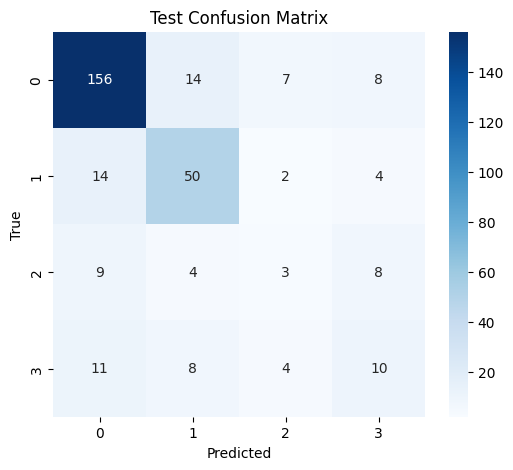

Model saved to roberta-hate-finetuned/


In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Random seed
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Model + Tokenizer
task='hate'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=4,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize datasets
train_ds = train_ds.map(tokenize, batched=True)
valid_ds = valid_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Format for PyTorch
columns = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=columns)
valid_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)


epochs = 5
lr = 2e-5

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# W&B init
wandb.init(
    project="sexism_detection",
    config={
        "entity": WANDB_USER,
        "model": MODEL,
        "epochs": epochs,
        "lr": lr,
        "batch_size": 16,
    }
)

def evaluate(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            trues.extend(batch["labels"].cpu().numpy())

    f1 = f1_score(trues, preds, average="macro")
    return f1, preds, trues

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k,v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    f1_val, _, _ = evaluate(model, valid_loader)

    wandb.log({
        "train_loss": avg_loss,
        "valid_f1": f1_val,
        "epoch": epoch
    })

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Macro-F1: {f1_val:.4f}")


# Final validation
f1_val, val_preds, val_trues = evaluate(model, valid_loader)
print("\nFinal Validation Macro-F1:", f1_val)
print(classification_report(val_trues, val_preds))


# Test
f1_test, test_preds, test_trues = evaluate(model, test_loader)
print("\nTest Macro-F1:", f1_test)
print(classification_report(test_trues, test_preds))

# Plot confusion matrix
cm = confusion_matrix(test_trues, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

wandb.log({"test_f1": f1_test})

# Save model
model.save_pretrained("roberta-hate-finetuned")
tokenizer.save_pretrained("roberta-hate-finetuned")
print("Model saved to roberta-hate-finetuned/")
